<a href="https://colab.research.google.com/github/JManuelRG/Herramientas-NCBI/blob/main/An%C3%A1lisis%20Filogen%C3%A9tico/Arbol_filogenetico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análisis Filogenético Automático

Especie a analizar: Staphylococcus aureus
  Buscando secuencias MLSA...
  [███████] 7/7  yqiL        


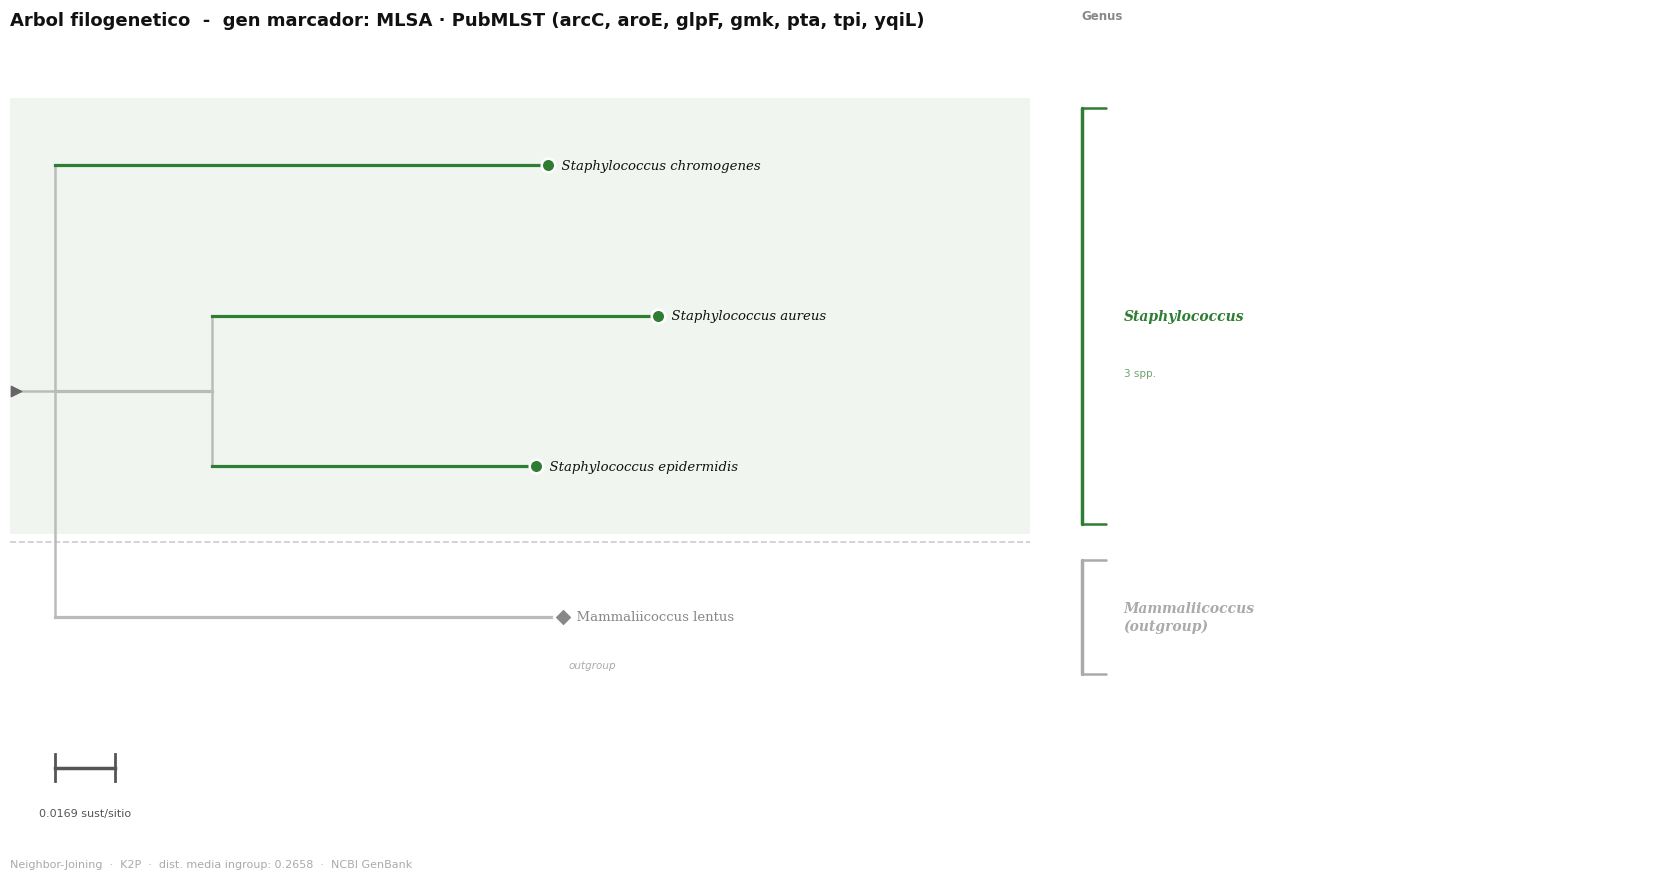

  Buscando panel de resistencia...
  [████████████] 12/12  graF        


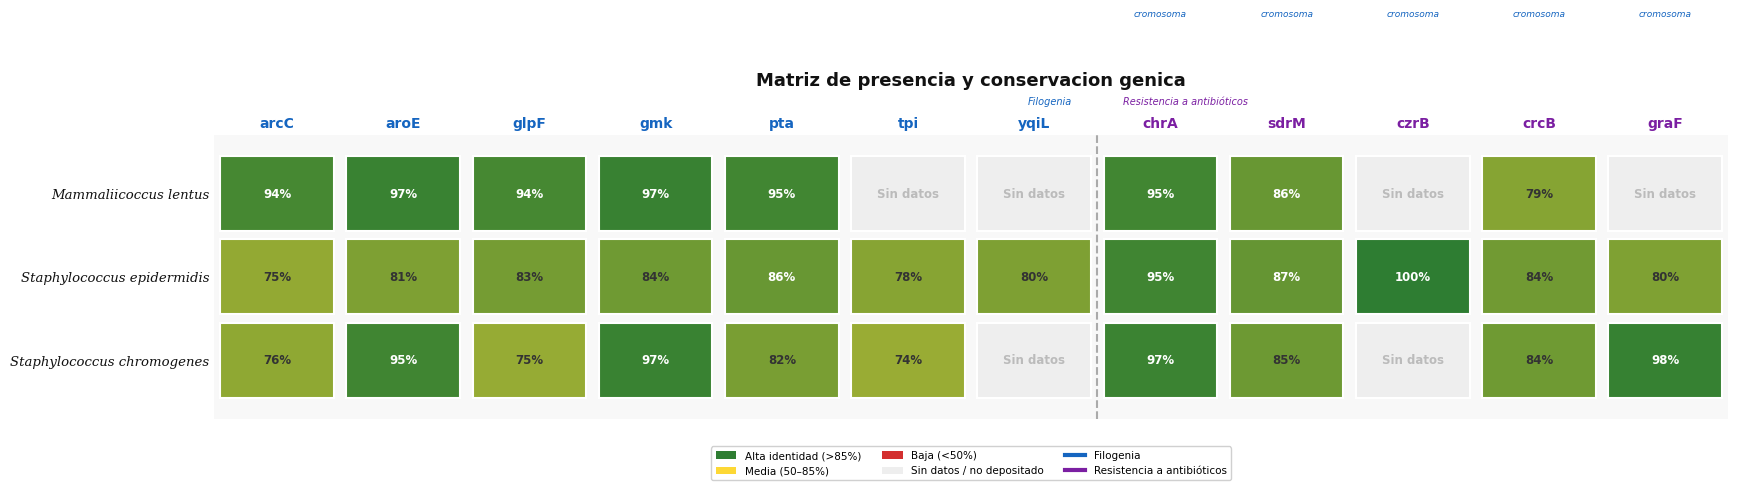

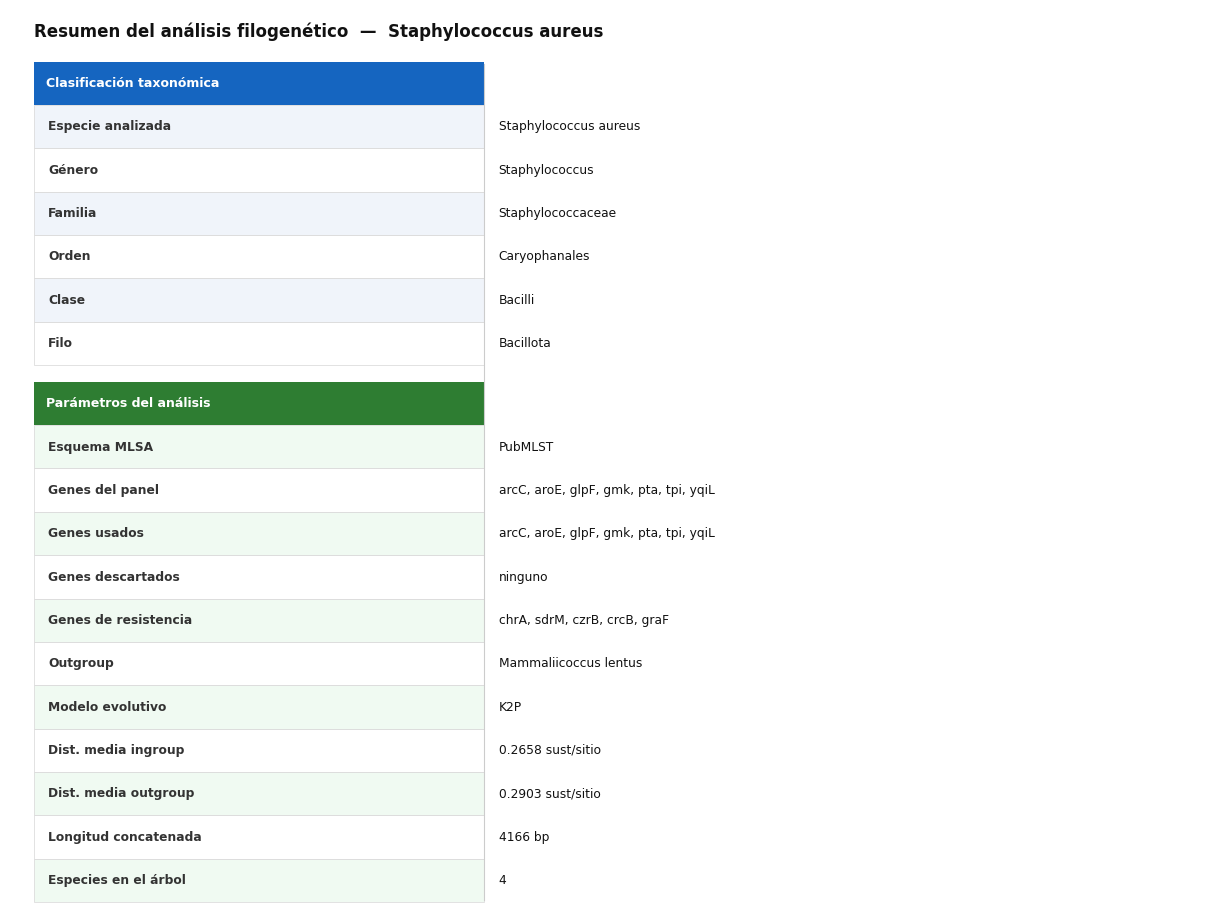

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
    "biopython", "requests", "matplotlib", "numpy", "--quiet",
    "--break-system-packages"], check=False)

import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from io import StringIO
from collections import defaultdict

from Bio import Entrez, SeqIO
from Bio.Align import PairwiseAligner
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor
from Bio import Phylo

Entrez.email = "phylo_tool@bioinformatica.mx"

import urllib.request, json
import pandas as pd

PUBMLST_REST = "https://rest.pubmlst.org"

def _pubmlst_get(url):
    try:
        req = urllib.request.Request(
            url,
            headers={"User-Agent": "PhyloTool/2.0", "Accept": "application/json"}
        )
        with urllib.request.urlopen(req, timeout=20) as resp:
            raw = resp.read()
        if not raw or raw[:1] in (b"<", b" "):
            return None
        return json.loads(raw)
    except Exception:
        return None

def _pubmlst_buscar_bd(genero):
    genero_lower = genero.lower()

    NOMBRES_PUBMLST = {
        "acinetobacter": "pubmlst_abaumannii_seqdef",
        "klebsiella":    "pubmlst_klebsiella_seqdef",
        "escherichia":   "pubmlst_ecoli_seqdef",
        "staphylococcus":"pubmlst_saureus_seqdef",
        "streptococcus": "pubmlst_spneumoniae_seqdef",
        "pseudomonas":   "pubmlst_paeruginosa_seqdef",
        "campylobacter": "pubmlst_campylobacter_seqdef",
        "neisseria":     "pubmlst_neisseria_seqdef",
        "listeria":      "pubmlst_listeria_seqdef",
        "mycobacterium": "pubmlst_mycobacteria_seqdef",
    }

    nombres_a_probar = []
    if genero_lower in NOMBRES_PUBMLST:
        nombres_a_probar.append(NOMBRES_PUBMLST[genero_lower])
    nombres_a_probar.append(f"pubmlst_{genero_lower}_seqdef")

    for nombre_bd in nombres_a_probar:
        url_directa = f"{PUBMLST_REST}/db/{nombre_bd}"
        datos = _pubmlst_get(url_directa)
        if datos and ("description" in datos or "schemes" in datos):
            return url_directa, datos.get("description", genero)

    datos_lista = _pubmlst_get(f"{PUBMLST_REST}/db")
    if not datos_lista:
        return None, None

    if isinstance(datos_lista, list):
        bases = datos_lista
    else:
        bases = datos_lista.get("databases", [])

    for bd in bases:
        href = bd.get("href", "")
        desc = bd.get("description", "").lower()
        if "seqdef" in href and genero_lower in desc:
            return href, bd.get("description", "")

    return None, None

def _normalizar_locus(nombre):
    PREFIJOS = ["Oxf_", "Pas_", "OXF_", "PAS_", "abaumannii_", "AB_",
                "MLST_", "mlst_", "ST_"]
    for pref in PREFIJOS:
        if nombre.startswith(pref):
            nombre = nombre[len(pref):]
            break

    if nombre.isdigit() or nombre.upper().startswith("BACT"):
        return None

    return nombre if (1 < len(nombre) <= 15) else None

def _pubmlst_obtener_loci(url_bd):
    for esquema_id in ["1", "2"]:
        url_loci = f"{url_bd}/schemes/{esquema_id}/loci"
        datos = _pubmlst_get(url_loci)
        if datos and datos.get("loci"):
            nombres = []
            for locus_url in datos["loci"]:
                raw = locus_url.rstrip("/").split("/")[-1]
                nombre = _normalizar_locus(raw)
                if nombre and nombre not in nombres:
                    nombres.append(nombre)
            if nombres:
                return nombres

    datos_esquemas = _pubmlst_get(f"{url_bd}/schemes")
    if not datos_esquemas:
        return []

    for esquema in datos_esquemas.get("schemes", []):
        desc = esquema.get("description", "").lower()
        if "mlst" in desc or "multilocus" in desc:
            url_sch = esquema.get("scheme", "")
            if url_sch:
                datos_sch = _pubmlst_get(f"{url_sch}/loci")
                if datos_sch and datos_sch.get("loci"):
                    nombres = []
                    for locus_url in datos_sch["loci"]:
                        raw = locus_url.rstrip("/").split("/")[-1]
                        nombre = _normalizar_locus(raw)
                        if nombre and nombre not in nombres:
                            nombres.append(nombre)
                    if nombres:
                        return nombres
    return []

ESQUEMAS_MLSA = {
    "acinetobacter":     ["gltA", "gyrB", "gdhB", "recA", "cpn60", "gpi", "rpoD"],
    "klebsiella":        ["gapA", "infB", "mdh", "pgi", "phoE", "rpoB", "tonB"],
    "escherichia":       ["adk", "fumC", "gyrB", "icd", "mdh", "purA", "recA"],
    "pseudomonas":       ["acs", "aroE", "guaA", "mutL", "nuoD", "ppsA", "trpE"],
    "salmonella":        ["aroC", "dnaN", "hemD", "hisD", "purE", "sucA", "thrA"],
    "vibrio":            ["adk", "gyrB", "mdh", "metE", "pntA", "purM", "pyrC"],
    "haemophilus":       ["adk", "atpG", "frdB", "fucK", "mdh", "pgi", "recA"],
    "legionella":        ["flaA", "pilE", "asd", "mip", "mompS", "proA", "neuA"],
    "proteus":           ["gapA", "gyrB", "mdh", "nuoD", "pntA", "putP", "rpoD"],
    "serratia":          ["dnaA", "fyuA", "gyrB", "leuS", "pyrC", "rpoD", "serC"],
    "yersinia":          ["adk", "aroA", "glnA", "hemH", "nuoD", "thrA", "dnaN"],
    "aeromonas":         ["gltA", "gyrB", "ileS", "metG", "ppsA", "recA", "rpoD"],
    "shewanella":        ["gyrB", "mdh", "nuoD", "recA", "pyrC", "rpoD", "dnaN"],
    "stenotrophomonas":  ["atpD", "gltB", "gyrB", "nuoD", "ppsA", "recA", "smdA"],
    "xanthomonas":       ["atpD", "dnaK", "efp", "fyuA", "glnA", "gyrB", "rpoD"],
    "moraxella":         ["abcZ", "adk", "aroE", "fumC", "gdh", "pdhC", "pgm"],
    "pasteurella":       ["adk", "est", "gdh", "mdh", "pgi", "pgm", "6pgd"],
    "mannheimia":        ["adk", "est", "gdh", "mdh", "pgi", "pgm", "6pgd"],
    "aggregatibacter":   ["adk", "atpG", "frdB", "fucK", "mdh", "pgi", "recA"],
    "coxiella":          ["adk", "aroE", "dnaA", "dnaK", "groEL", "guaA", "rpoB"],
    "burkholderia":      ["atpD", "gltB", "gyrB", "recA", "lepA", "phaC", "trpB"],
    "ralstonia":         ["atpD", "gltB", "gyrB", "lepA", "nusA", "rpoB", "gltA"],
    "acidovorax":        ["atpD", "gltB", "gyrB", "lepA", "nusA", "rpoB", "gltA"],
    "achromobacter":     ["atpD", "gltB", "gyrB", "nusA", "rpoB", "nuoD", "gltA"],
    "alcaligenes":       ["aroE", "gyrB", "lepA", "recA", "rpoB", "nuoD", "gltA"],
    "neisseria":         ["abcZ", "adk", "aroE", "fumC", "gdh", "pdhC", "pgm"],
    "bordetella":        ["adk", "fumC", "glyA", "tyrB", "icd", "trpC", "pdhA"],
    "methylobacillus":   ["atpD", "gyrB", "lepA", "recA", "rpoB", "gltA", "nuoD"],
    "brucella":          ["gap", "aroA", "glk", "dnaK", "gyrB", "trpE", "cobQ"],
    "bartonella":        ["16S", "ftsZ", "gltA", "groEL", "nlpD", "ribC", "rpoB"],
    "rickettsia":        ["atpA", "dnaK", "glnA", "gltA", "groEL", "recA", "rpoB"],
    "agrobacterium":     ["atpD", "glnA", "gltA", "gyrB", "recA", "rpoB", "trpC"],
    "rhizobium":         ["atpD", "glnA", "gltA", "gyrB", "recA", "rpoB", "trpC"],
    "mesorhizobium":     ["atpD", "glnA", "gltA", "gyrB", "recA", "rpoB", "trpC"],
    "caulobacter":       ["atpD", "gyrB", "recA", "rpoB", "trpC", "clpB", "rplB"],
    "sphingomonas":      ["atpD", "gyrB", "recA", "rpoB", "trpC", "ureA", "16S"],
    "methylobacterium":  ["atpD", "gyrB", "lepA", "recA", "rpoB", "gltA", "nuoD"],
    "helicobacter":      ["atpA", "efp", "mutY", "ppa", "trpC", "ureI", "yphC"],
    "campylobacter":     ["aspA", "glnA", "gltA", "glyA", "pgm", "tkt", "uncA"],
    "wolinella":         ["aspA", "glnA", "gltA", "glyA", "pgm", "tkt", "uncA"],
    "staphylococcus":    ["arcC", "aroE", "glpF", "gmk", "pta", "tpi", "yqiL"],
    "streptococcus":     ["aroE", "gdh", "gki", "recP", "spi", "xpt", "ddl"],
    "enterococcus":      ["atpA", "ddl", "gdh", "gyd", "purK", "pstS", "adk"],
    "listeria":          ["abcZ", "bglA", "cat", "dapE", "dat", "ldh", "lhkA"],
    "bacillus":          ["glp", "gmk", "ilvD", "pta", "pur", "pycA", "tpiA"],
    "clostridium":       ["adk", "atpA", "dxr", "glyA", "recA", "sodA", "tpi"],
    "lactobacillus":     ["atpA", "ddl", "gdh", "gki", "mutS", "pheS", "xpt"],
    "lactococcus":       ["atpA", "ddl", "gki", "mutS", "pheS", "purK", "pyrG"],
    "paenibacillus":     ["atpD", "dnaK", "gyrA", "recA", "rpoB", "rpoD", "trpB"],
    "geobacillus":       ["atpD", "dnaK", "gyrA", "recA", "rpoB", "rpoD", "trpB"],
    "lysinibacillus":    ["atpD", "dnaK", "gyrA", "recA", "rpoB", "rpoD", "trpB"],
    "brevibacillus":     ["atpD", "dnaK", "gyrA", "recA", "rpoB", "rpoD", "trpB"],
    "anoxybacillus":     ["atpD", "dnaK", "gyrA", "recA", "rpoB", "rpoD", "trpB"],
    "sporosarcina":      ["atpD", "dnaK", "gyrA", "recA", "rpoB", "rpoD", "trpB"],
    "exiguobacterium":   ["atpD", "dnaK", "gyrA", "recA", "rpoB", "rpoD", "trpB"],
    "planococcus":       ["atpD", "dnaK", "gyrA", "recA", "rpoB", "rpoD", "trpB"],
    "leuconostoc":       ["atpA", "ddl", "gki", "mutS", "pheS", "purK", "pyrG"],
    "pediococcus":       ["atpA", "ddl", "gki", "mutS", "pheS", "purK", "pyrG"],
    "weissella":         ["atpA", "ddl", "gki", "mutS", "pheS", "purK", "pyrG"],
    "carnobacterium":    ["atpA", "ddl", "gki", "mutS", "pheS", "purK", "pyrG"],
    "erysipelothrix":    ["atpA", "ddl", "gki", "mutS", "sodA", "tuf", "16S"],
    "streptomyces":      ["atpD", "gyrB", "recA", "rpoB", "trpB", "16S", "gyrA"],
    "mycobacterium":     ["atpE", "efp", "eno", "gid", "glnA1", "ldh", "rpoB"],
    "corynebacterium":   ["atpA", "dnaE", "dnaK", "fusA", "leuA", "odhA", "rpoB"],
    "nocardia":          ["atpA", "gltA", "gyrB", "lepA", "nuoD", "recA", "rpoB"],
    "rhodococcus":       ["atpA", "dnaN", "gltA", "gyrB", "murC", "recA", "secA"],
    "gordonia":          ["atpA", "gltA", "gyrB", "lepA", "recA", "rpoB", "secA"],
    "tsukamurella":      ["atpA", "gltA", "gyrB", "lepA", "recA", "rpoB", "secA"],
    "dietzia":           ["atpA", "gltA", "gyrB", "lepA", "recA", "rpoB", "secA"],
    "williamsia":        ["atpA", "gltA", "gyrB", "lepA", "recA", "rpoB", "secA"],
    "micrococcus":       ["atpD", "gyrB", "lysS", "recA", "rpoB", "sodA", "tuf"],
    "arthrobacter":      ["atpD", "dnaK", "gyrB", "recA", "rpoB", "sodA", "tuf"],
    "cellulomonas":      ["atpD", "gyrB", "recA", "rpoB", "sodA", "tuf", "dnaK"],
    "brevibacterium":    ["atpD", "dnaK", "gyrB", "recA", "rpoB", "sodA", "tuf"],
    "rothia":            ["atpD", "dnaK", "gyrB", "recA", "rpoB", "secA", "tuf"],
    "actinomyces":       ["atpA", "gapdh", "gltA", "gyrB", "lepA", "pgm", "recA"],
    "propionibacterium": ["aroE", "dnaN", "hemH", "hlb", "sodA", "tuf", "zwf"],
    "micromonospora":    ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "saccharopolyspora": ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "amycolatopsis":     ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "nocardiopsis":      ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "pseudonocardia":    ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "saccharothrix":     ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "kitasatospora":     ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "streptosporangium": ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "nonomuraea":        ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "thermomonospora":   ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "thermoactinomyces": ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "thermobifida":      ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "kribbella":         ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "actinomadura":      ["atpD", "gyrB", "recA", "rpoB", "trpB", "gyrA", "16S"],
    "frankia":           ["atpD", "dnaK", "glnA", "gyrB", "recA", "rpoB", "trpB"],
    "bacteroides":       ["cfiA", "glyQ", "gyrA", "ndk", "recA", "rpoB", "rt"],
    "prevotella":        ["dnaK", "gyrB", "recA", "rpoB", "tuf", "hsp60", "16S"],
    "porphyromonas":     ["atpA", "dnaK", "gyrB", "recA", "rpoB", "tuf", "16S"],
    "capnocytophaga":    ["atpA", "gltA", "lepA", "recA", "rpoB", "secA", "sodA"],
    "flavobacterium":    ["atpA", "clpX", "dnaK", "groEL", "gyrA", "recA", "rpoB"],
    "chryseobacterium":  ["gltA", "gyrB", "lepA", "nuoD", "recA", "rpoB", "rpoD"],
    "elizabethkingia":   ["atpA", "cpn60", "gltA", "gyrB", "recA", "rpoB", "rpoD"],
    "cytophaga":         ["gyrB", "recA", "rpoB", "rpoD", "secY", "tuf", "16S"],
    "flexibacter":       ["atpA", "gyrB", "recA", "rpoB", "secY", "tuf", "16S"],
    "fusobacterium":     ["atpA", "dnaA", "fumC", "glyA", "lepA", "recA", "sdaA"],
    "leptotrichia":      ["atpA", "dnaA", "fumC", "glyA", "lepA", "recA", "sdaA"],
    "borrelia":          ["clpA", "clpX", "nifS", "pepX", "pyrG", "recG", "rplB"],
    "treponema":         ["dnaA", "flaA", "pntA", "pyrG", "recA", "rpoD", "tmpC"],
    "leptospira":        ["glmU", "pntA", "sucA", "tpiA", "pfpI", "mreA", "caiB"],
    "mycoplasma":        ["gltX", "gyrB", "lepA", "rpoB", "tuf", "typS", "uvrC"],
    "ureaplasma":        ["cdsA", "gyrB", "mba", "ureA", "ureG", "parC", "16S"],
    "spiroplasma":       ["gyrB", "rpoB", "tuf", "ftsY", "pyrG", "rplB", "16S"],
    "acholeplasma":      ["adk", "glpF", "gyrB", "rpoB", "tuf", "16S", "pdhA"],
    "chlamydia":         ["enoA", "fumC", "gidA", "hemN", "hflX", "oppA", "16S"],
    "chlamydophila":     ["enoA", "fumC", "gidA", "hemN", "hflX", "oppA", "16S"],
    "francisella":       ["atpA", "carA", "dnaG", "groEL", "lepA", "rpoB", "sdhA"],
    "synechococcus":     ["atpA", "carA", "glnA", "gltA", "gyrB", "recA", "rpoC1"],
    "synechocystis":     ["atpA", "carA", "glnA", "gltA", "gyrB", "recA", "rpoC1"],
    "nostoc":            ["atpD", "gltA", "gyrB", "recA", "rpoB", "rpoC1", "rnpB"],
    "anabaena":          ["atpD", "gltA", "gyrB", "recA", "rpoB", "rpoC1", "rnpB"],
    "prochlorococcus":   ["atpB", "carA", "glnA", "gltA", "gyrB", "recA", "rpoA"],
    "chlorobium":        ["acsF", "fmo", "gltA", "gyrB", "recA", "rpoB", "fdhB"],
    "chloroflexus":      ["atpD", "gyrB", "recA", "rpoB", "secY", "tuf", "23S"],
    "thermus":           ["dnaK", "gap", "glnS", "gyrB", "lepA", "recA", "rpoB"],
    "deinococcus":       ["dnaK", "gyrA", "gyrB", "recA", "rpoB", "tuf", "gap"],
    "thermotoga":        ["dnaK", "efp", "frr", "glyA", "lepA", "recA", "rpoB"],
    "aquifex":           ["atpD", "carA", "gyrB", "recA", "rpoB", "secY", "tuf"],
}

def obtener_genes_mlsa(nombre_especie, reino):
    genero = nombre_especie.split()[0].lower()

    url_bd, nombre_bd = _pubmlst_buscar_bd(nombre_especie.split()[0])
    if url_bd:
        loci = _pubmlst_obtener_loci(url_bd)
        if loci:
            return loci, "PubMLST"

    if genero in ESQUEMAS_MLSA:
        genes = ESQUEMAS_MLSA[genero]
        return genes, "Esquemas MLSA estándar"

    return None, None


NOMBRE_GEN = {
    "16S": "16S ribosomal RNA",
    "rpoB": "RNA polymerase beta subunit",
    "gyrB": "DNA gyrase subunit B",
    "recA": "recombinase A",
    "groEL": "chaperonin GroEL",
    "ITS": "internal transcribed spacer",
    "BenA": "beta-tubulin",
    "CaM": "calmodulin",
    "RPB2": "RNA polymerase II",
    "rbcL": "ribulose bisphosphate carboxylase",
    "matK": "maturase K",
    "trnL": "tRNA-Leu",
    "COX1": "cytochrome c oxidase subunit 1",
    "cytb": "cytochrome b",
    "12S": "12S ribosomal RNA",
}

COLORES_GRUPOS = [
    "#1565C0", "#2E7D32", "#6A1B9A", "#E65100",
    "#00695C", "#AD1457", "#4527A0", "#558B2F",
]

COLORES_RAMAS = [
    "#1976D2", "#388E3C", "#7B1FA2", "#F57C00",
    "#00897B", "#C62828", "#5C6BC0", "#689F38",
    "#0097A7", "#EF6C00", "#8E24AA", "#43A047",
]

def _entrez_call(func, **kwargs):
    for intento in range(4):
        try:
            handle = func(**kwargs)
            result = Entrez.read(handle)
            handle.close()
            return result
        except Exception:
            time.sleep(1.5 * (intento + 1))
    return None

def _efetch_text(db, id_, rettype, retmode="text"):
    for intento in range(4):
        try:
            handle = Entrez.efetch(db=db, id=id_, rettype=rettype, retmode=retmode)
            text = handle.read()
            handle.close()
            return text
        except Exception:
            time.sleep(1.5 * (intento + 1))
    return None

def _corregir_nombre_especie(nombre):
    partes = nombre.strip().split()
    if partes:
        partes[0] = partes[0].capitalize()
    nombre_norm = " ".join(partes)
    if nombre_norm != nombre:
        pass

    rec = _entrez_call(Entrez.esearch, db="taxonomy",
                       term=f'"{nombre_norm}"[Scientific Name]', retmax=1)
    if rec and rec.get("IdList"):
        return nombre_norm

    rec2 = _entrez_call(Entrez.esearch, db="taxonomy",
                        term=nombre_norm, retmax=3)
    if rec2 and rec2.get("IdList"):
        rec3 = _entrez_call(Entrez.efetch, db="taxonomy",
                            id=rec2["IdList"][0], retmode="xml")
        if rec3:
            nombre_correcto = rec3[0].get("ScientificName", "")
            if nombre_correcto and nombre_correcto.lower() != nombre.lower():
                return nombre_correcto

    if len(partes) >= 2:
        rec4 = _entrez_call(Entrez.esearch, db="taxonomy",
                            term=f'"{partes[0]}"[Genus]', retmax=1)
        if rec4 and rec4.get("IdList"):
            return nombre_norm

    return nombre_norm

def obtener_taxonomia(nombre_especie):
    rec = _entrez_call(Entrez.esearch, db="taxonomy",
                       term=f'"{nombre_especie}"[Scientific Name]', retmax=1)
    if not rec or not rec.get("IdList"):
        nombre_corregido = _corregir_nombre_especie(nombre_especie)
        rec = _entrez_call(Entrez.esearch, db="taxonomy",
                           term=f'"{nombre_corregido}"[Scientific Name]', retmax=1)
        if not rec or not rec.get("IdList"):
            rec = _entrez_call(Entrez.esearch, db="taxonomy",
                               term=nombre_corregido, retmax=1)
    if not rec or not rec.get("IdList"):
        return None

    taxid = rec["IdList"][0]
    rec2 = _entrez_call(Entrez.efetch, db="taxonomy", id=taxid, retmode="xml")
    if not rec2:
        return None

    taxon = rec2[0]
    lineage = {r["Rank"]: r["ScientificName"] for r in taxon.get("LineageEx", []) if r["Rank"] != "no rank"}
    lineage["species"] = taxon.get("ScientificName", nombre_especie)
    lineage["taxid"] = taxid

    reino = None
    for r in ["Bacteria", "Archaea", "Fungi", "Viridiplantae", "Metazoa"]:
        if r in str(taxon.get("Lineage", "")):
            reino = r
            break
    lineage["reino"] = reino or "default"

    return lineage

def _nombre_valido(nombre):
    palabras = nombre.split()
    if len(palabras) != 2:
        return False
    if " sp." in nombre or "sp." in palabras[1]:
        return False
    if any(c.isdigit() for c in nombre):
        return False
    if not palabras[1][0].islower():
        return False
    if palabras[1] in ("sp", "spp", "cf", "aff", "nov", "str"):
        return False
    return True

def _buscar_especies_genero(genero, gen_marcador="16S", max_especies=10):
    termino_gen = NOMBRE_GEN.get(gen_marcador, gen_marcador)
    especies = []
    seen = set()

    queries = [
        f'"{genero}"[Organism] AND "{termino_gen}"[Title] AND complete[Title] AND 500:2000[SLEN]',
        f'"{genero}"[Organism] AND "{gen_marcador}"[All Fields] AND 500:2000[SLEN]',
        f'"{genero}"[Organism] AND "{termino_gen}"[All Fields] AND 300:3000[SLEN]',
    ]

    for query in queries:
        if len(especies) >= max_especies:
            break
        rec = _entrez_call(Entrez.esearch, db="nucleotide", term=query, retmax=100, sort="relevance")
        if not rec or not rec.get("IdList"):
            continue

        ids = rec["IdList"][:40]
        for chunk_start in range(0, len(ids), 10):
            chunk = ids[chunk_start:chunk_start+10]
            gb_text = _efetch_text("nucleotide", ",".join(chunk), "gb")
            if not gb_text:
                continue
            for line in gb_text.split("\n"):
                if line.strip().startswith("ORGANISM"):
                    nombre = line.replace("ORGANISM", "").strip()
                    if _nombre_valido(nombre) and nombre not in seen:
                        seen.add(nombre)
                        especies.append(nombre)
                        if len(especies) >= max_especies:
                            break
            time.sleep(0.2)
            if len(especies) >= max_especies:
                break

    return list(dict.fromkeys(especies))[:max_especies]

def _buscar_outgroup(taxonomia, gen_marcador):
    genero = taxonomia.get("genus", "")
    termino_gen = NOMBRE_GEN.get(gen_marcador, gen_marcador)

    for nivel in ["family", "order", "class", "phylum"]:
        grupo_taxonomico = taxonomia.get(nivel, "")
        if not grupo_taxonomico:
            continue

        candidatos = []

        for query in [
            f'"{grupo_taxonomico}"[Organism] AND "{termino_gen}"[Title]' +
            f' NOT "{genero}"[Organism] AND 500:2000[SLEN] AND complete[Title]',
            f'"{grupo_taxonomico}"[Organism] AND "{gen_marcador}"[All Fields]' +
            f' NOT "{genero}"[Organism] AND 500:2000[SLEN]',
        ]:
            rec = _entrez_call(Entrez.esearch, db="nucleotide", term=query, retmax=40)
            if not rec or not rec.get("IdList"):
                continue

            gb = _efetch_text("nucleotide", ",".join(rec["IdList"][:25]), "gb")
            if not gb:
                continue

            for line in gb.split("\n"):
                if line.strip().startswith("ORGANISM"):
                    nombre = line.replace("ORGANISM", "").strip()
                    palabras = nombre.split()
                    if (len(palabras) == 2 and
                        palabras[0] != genero and
                        _nombre_valido(nombre) and
                        nombre not in candidatos):
                        candidatos.append(nombre)
            time.sleep(0.3)
            if len(candidatos) >= 6:
                break

        for candidato in list(dict.fromkeys(candidatos))[:10]:
            seq, acc = _buscar_secuencia_gen(candidato, gen_marcador)
            if seq:
                return candidato, acc
            time.sleep(0.25)

    return None, None

TERMINOS_FUNCION = {
    "Bacteria": [
        "resistance", "beta-lactamase", "efflux pump", "carbapenem",
        "aminoglycoside", "tetracycline", "chloramphenicol", "fluoroquinolone",
        "virulence", "adhesin", "hemolysin", "toxin", "invasion",
        "siderophore", "biofilm", "capsule", "fimbria", "pili",
        "outer membrane protein", "porin", "secretion system",
        "penicillin-binding", "transpeptidase",
    ],
    "default": [
        "resistance", "efflux", "virulence", "toxin",
        "defense", "stress", "adhesin", "biofilm",
    ],
}

def _obtener_genoma_referencia(genero, especie_query):
    for status_filter in [
        f'"{genero}"[Organism] AND "reference genome"[RefSeq Status]',
        f'"{especie_query}"[Organism] AND "representative genome"[RefSeq Status]',
        f'"{genero}"[Organism] AND "representative genome"[RefSeq Status]',
        f'"{especie_query}"[Organism] AND latest_refseq[filter]',
    ]:
        rec = _entrez_call(Entrez.esearch, db="assembly",
                           term=status_filter, retmax=3, sort="relevance")
        if rec and rec.get("IdList"):
            summary = _entrez_call(Entrez.esummary, db="assembly",
                                   id=rec["IdList"][0], report="full")
            if summary and "DocumentSummarySet" in summary:
                doc = summary["DocumentSummarySet"]["DocumentSummary"][0]
                accession = doc.get("AssemblyAccession", "")
                ftp_path   = doc.get("FtpPath_RefSeq", "")
                if accession.startswith("GCF_") and ftp_path:
                    return accession, ftp_path
        time.sleep(0.3)
    return None, None

def _descargar_feature_table(ftp_path, accession):
    import urllib.request, gzip

    nombre_base = ftp_path.rstrip("/").split("/")[-1]
    url = f"{ftp_path}/{nombre_base}_feature_table.txt.gz"

    for intento in range(3):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "BioTool/1.0"})
            with urllib.request.urlopen(req, timeout=30) as resp:
                data_gz = resp.read()
            texto = gzip.decompress(data_gz).decode("utf-8", errors="ignore")
            return texto
        except Exception as e:
            time.sleep(2 * (intento + 1))
    return None

def _extraer_genes_feature_table(texto_ft, terminos, genes_mlsa_activos=None):
    genes_mlsa_activos = genes_mlsa_activos or set()

    CATEGORIAS = [
        ("resistencia",          ["resistance", "beta-lactamase", "carbapenem",
                                  "aminoglycoside", "tetracycline", "chloramphenicol",
                                  "fluoroquinolone", "penicillin-binding", "transpeptidase",
                                  "efflux", "multidrug"]),
        ("virulencia_adhesion",  ["adhesin", "fimbria", "pili", "biofilm",
                                  "attachment", "colonization"]),
        ("virulencia_toxina",    ["toxin", "hemolysin", "cytotoxin", "exotoxin",
                                  "phospholipase", "protease", "lipase"]),
        ("virulencia_secrecion", ["secretion system", "type iii", "type vi",
                                  "t3ss", "t6ss", "tss", "type iv"]),
        ("membrana",             ["outer membrane protein", "porin", "omp",
                                  "surface", "capsule", "lipoprotein"]),
        ("sideroforo",           ["siderophore", "iron acquisition", "receptor",
                                  "tonb", "ferric"]),
    ]

    genes_por_categoria = {cat: {} for cat, _ in CATEGORIAS}
    cabecera_vista = False

    for linea in texto_ft.split("\n"):
        if linea.startswith("#"):
            cabecera_vista = True
            continue
        if not cabecera_vista or not linea.strip():
            continue

        cols = linea.split("\t")
        if len(cols) < 15:
            continue

        feature_type = cols[0].strip()
        if feature_type not in ("CDS", "gene"):
            continue

        seq_type      = cols[4].strip().lower() if len(cols) > 4 else ""
        assembly_unit = cols[3].strip()         if len(cols) > 3 else ""
        nombre_producto = cols[13].strip().lower()
        simbolo_gen     = cols[14].strip()

        if "plasmid" in seq_type or "plasmid" in assembly_unit.lower():
            localizacion = "plásmido"
        elif seq_type in ("chromosome", "genomic") or "primary assembly" in assembly_unit.lower():
            localizacion = "cromosoma"
        else:
            localizacion = "cromosoma"

        if not simbolo_gen or len(simbolo_gen) < 2 or len(simbolo_gen) > 15:
            continue
        if simbolo_gen in GENES_EXCLUIR_MLSA:
            continue
        if simbolo_gen in genes_mlsa_activos:
            continue
        if any(simbolo_gen.lower().startswith(p) for p in ["hyp", "orf", "unk"]):
            continue
        if any(w in nombre_producto for w in
               ["hypothetical", "uncharacterized", "transposase",
                "integrase", "phage", "insertion sequence"]):
            continue

        for categoria, keywords in CATEGORIAS:
            if any(k in nombre_producto for k in keywords):
                if simbolo_gen not in genes_por_categoria[categoria]:
                    genes_por_categoria[categoria][simbolo_gen] = {
                        "producto": nombre_producto,
                        "localizacion": localizacion,
                    }
                break

    resultado = {}
    orden_categorias = [
        "resistencia", "virulencia_toxina", "virulencia_adhesion",
        "sideroforo", "membrana", "virulencia_secrecion",
    ]
    for cat in orden_categorias:
        for gen, info in genes_por_categoria[cat].items():
            resultado[gen] = {
                "producto":      info["producto"],
                "categoria":     cat,
                "localizacion":  info["localizacion"],
            }

    return resultado

GENES_EXCLUIR_MLSA = {
    "rrs", "rrl", "rrf", "rrn",
    "tuf", "fusA", "infB", "tsf",
    "dnaA", "dnaK", "dnaN",
    "atpA", "atpB", "atpD",
    "16S", "23S", "5S",
}

def _genes_especificos_genero(genero, reino, max_genes=5, especie_query=""):
    genero_lower = genero.lower()
    genes_mlsa_activos = set(ESQUEMAS_MLSA.get(genero_lower, []))

    terminos = TERMINOS_FUNCION.get(reino, TERMINOS_FUNCION["default"])
    accession, ftp_path = _obtener_genoma_referencia(genero, especie_query)
    if not accession:
        return [], {}

    texto_ft = _descargar_feature_table(ftp_path, accession)
    if not texto_ft:
        return [], {}

    genes_candidatos = _extraer_genes_feature_table(texto_ft, terminos, genes_mlsa_activos)
    if not genes_candidatos:
        return [], {}

    CUOTAS = {"resistencia": max_genes}
    seleccionados_por_cat = {cat: [] for cat in CUOTAS}
    for simbolo, info in genes_candidatos.items():
        cat = info["categoria"]
        cuota = CUOTAS.get(cat, 0)
        if cuota > 0 and len(seleccionados_por_cat.get(cat, [])) < cuota:
            seleccionados_por_cat.setdefault(cat, []).append(simbolo)

    candidatos_priorizados = seleccionados_por_cat.get("resistencia", [])
    if len(candidatos_priorizados) < max_genes:
        for cat in ["virulencia_toxina", "virulencia_adhesion", "sideroforo"]:
            for simbolo, info in genes_candidatos.items():
                if info["categoria"] == cat and simbolo not in candidatos_priorizados:
                    candidatos_priorizados.append(simbolo)
            if len(candidatos_priorizados) >= max_genes:
                break

    resultado = []
    localizacion_gen = {}
    for simbolo in candidatos_priorizados[:20]:
        if len(resultado) >= max_genes:
            break
        query_v = (f'"{genero}"[Organism] AND "{simbolo}"[Gene Name]'
                   f' AND 200:5000[SLEN]')
        rv = _entrez_call(Entrez.esearch, db="nucleotide", term=query_v, retmax=5)
        if rv and len(rv.get("IdList", [])) >= 1:
            resultado.append(simbolo)
            localizacion_gen[simbolo] = genes_candidatos[simbolo].get("localizacion", "cromosoma")
        time.sleep(0.2)

    return resultado, localizacion_gen

def _buscar_secuencia_gen(organismo, gen, longitud_ref=None):
    termino = NOMBRE_GEN.get(gen, gen)

    LONGITUDES_GEN = {
        "16S": (800,  1800),
        "rpoB":(600,  2000),
        "gyrB":(600,  2500),
        "recA":(200,  1500),
        "groEL":(500, 2000),
        "ITS":  (400, 1000),
        "BenA": (400, 1000),
        "CaM":  (400, 1000),
        "RPB2": (600, 2000),
        "rbcL": (400, 1500),
        "matK": (600, 2000),
        "trnL": (200, 1000),
        "COX1": (500, 2000),
        "cytb": (500, 2000),
        "12S":  (300, 1200),
    }

    if longitud_ref:
        lo = int(longitud_ref * 0.75)
        hi = int(longitud_ref * 1.25)
    elif gen in LONGITUDES_GEN:
        lo, hi = LONGITUDES_GEN[gen]
    else:
        lo, hi = 200, 5000

    rango = f"{lo}:{hi}[SLEN]"

    queries = [
        f'"{organismo}"[Organism] AND "{termino}"[Title] AND {rango}',
        f'"{organismo}"[Organism] AND "{gen}"[All Fields] AND {rango}',
        f'"{organismo}"[Organism] AND "{gen}"[Gene Name] AND {rango}',
        f'"{organismo}"[Organism] AND "{termino}"[All Fields] AND {rango}',
        f'"{organismo}"[Organism] AND "{gen}"[Gene Name]',
    ]

    max_len_absoluto = hi * 3

    for qi, query in enumerate(queries):
        rec = _entrez_call(Entrez.esearch, db="nucleotide", term=query,
                           retmax=8, sort="relevance")
        if not rec or not rec.get("IdList"):
            time.sleep(0.2)
            continue

        for uid in rec["IdList"][:5]:
            fasta = _efetch_text("nucleotide", uid, "fasta")
            if not fasta:
                continue
            try:
                sr = next(SeqIO.parse(StringIO(fasta), "fasta"))
                seq = str(sr.seq).upper().replace("N", "").replace("-", "")
                if len(seq) < 100:
                    continue
                if len(seq) > max_len_absoluto and qi < 4:
                    continue
                return seq[:hi], sr.id.split(".")[0]
            except Exception:
                continue
        time.sleep(0.25)
    return None, None

def _extraer_secuencias_alineadas(aln):
    coords1 = aln.aligned[0]
    coords2 = aln.aligned[1]
    seq1 = str(aln.target)
    seq2 = str(aln.query)

    res1, res2 = [], []
    pos1, pos2 = 0, 0

    bloques = list(zip(coords1, coords2))
    for (s1, e1), (s2, e2) in bloques:
        if s1 > pos1:
            res1.append(seq1[pos1:s1])
            res2.append("-" * (s1 - pos1))
        if s2 > pos2:
            res2.append(seq2[pos2:s2])
            res1.append("-" * (s2 - pos2))
        res1.append(seq1[s1:e1])
        res2.append(seq2[s2:e2])
        pos1, pos2 = e1, e2

    if pos1 < len(seq1):
        res1.append(seq1[pos1:])
        res2.append("-" * (len(seq1) - pos1))
    if pos2 < len(seq2):
        res2.append(seq2[pos2:])
        res1.append("-" * (len(seq2) - pos2))

    return "".join(res1), "".join(res2)

_COMP = str.maketrans("ACGT", "TGCA")

def _rev_comp(seq):
    return seq.translate(_COMP)[::-1]

def _alinear_score(aligner, s1, s2):
    try:
        aln = next(iter(aligner.align(s1, s2)))
        a1, a2 = _extraer_secuencias_alineadas(aln)
        longitud = sum(1 for c1, c2 in zip(a1, a2) if c1 != "-" and c2 != "-")
        if longitud == 0:
            return 0.0, None
        coincidencias = sum(c1 == c2 and c1 not in "-N" for c1, c2 in zip(a1, a2))
        return coincidencias / longitud, (a1, a2, longitud)
    except Exception:
        return 0.0, None

def _distancia_directa(seq1, seq2, modelo):
    aligner = PairwiseAligner()
    aligner.mode = "global"
    aligner.match_score = 2
    aligner.mismatch_score = -1
    aligner.open_gap_score = -2.5
    aligner.extend_gap_score = -0.5
    L = 1500
    s1, s2 = seq1[:L], seq2[:L]
    try:
        id_fwd, res_fwd = _alinear_score(aligner, s1, s2)
        id_rc,  res_rc  = _alinear_score(aligner, s1, _rev_comp(s2))
        res = res_fwd if id_fwd >= id_rc else res_rc
        if res is None:
            return 1.0
        a1, a2, longitud = res
        coincidencias = sum(c1 == c2 and c1 not in "-N" for c1, c2 in zip(a1, a2))
        p = max(0.0, 1.0 - coincidencias / longitud)
        if p == 0:
            return 0.0
        if modelo == "JC":
            arg = 1 - (4/3) * p
            return min(-0.75 * np.log(arg), 1.0) if arg > 0 else 1.0
        else:
            transitions = sum(
                1 for c1, c2 in zip(a1, a2)
                if c1 != "-" and c2 != "-" and c1 != c2
                and ((c1 in "AG" and c2 in "AG") or (c1 in "CT" and c2 in "CT"))
            )
            transversions = sum(
                1 for c1, c2 in zip(a1, a2)
                if c1 != "-" and c2 != "-" and c1 != c2
                and not ((c1 in "AG" and c2 in "AG") or (c1 in "CT" and c2 in "CT"))
            )
            P = transitions / longitud
            Q = transversions / longitud
            a_arg = 1 - 2*P - Q
            b_arg = 1 - 2*Q
            if a_arg <= 0 or b_arg <= 0:
                return min(p * 2, 1.0)
            return min(-0.5 * np.log(a_arg) - 0.25 * np.log(b_arg), 1.0)
    except Exception:
        return 1.0

def _construir_matriz(nombres, secuencias, outgroup_nombre=None):
    n = len(nombres)

    matriz_jc = [[0.0] * n for _ in range(n)]
    distancias_planas = []
    for i in range(n):
        for j in range(i):
            d = _distancia_directa(secuencias[i], secuencias[j], "JC")
            matriz_jc[i][j] = d
            matriz_jc[j][i] = d
            distancias_planas.append(d)

    media = np.mean(distancias_planas) if distancias_planas else 0
    modelo = "K2P" if media > 0.15 else "JC"

    if modelo == "JC":
        matriz = matriz_jc
    else:
        matriz = [[0.0] * n for _ in range(n)]
        for i in range(n):
            for j in range(i):
                d = _distancia_directa(secuencias[i], secuencias[j], "K2P")
                matriz[i][j] = d
                matriz[j][i] = d

    if outgroup_nombre and outgroup_nombre in nombres:
        og_idx = nombres.index(outgroup_nombre)
        ingroup_dists = []
        og_dists = []
        for i in range(n):
            for j in range(i):
                d = matriz[i][j]
                if i == og_idx or j == og_idx:
                    og_dists.append(d)
                else:
                    ingroup_dists.append(d)
        dist_ingroup = np.mean(ingroup_dists) if ingroup_dists else media
        dist_og      = np.mean(og_dists)      if og_dists      else 0.0
    else:
        dist_ingroup = media
        dist_og      = 0.0

    triangular = [row[:i+1] for i, row in enumerate(matriz)]
    return DistanceMatrix(nombres, triangular), modelo, dist_ingroup, dist_og

def _obtener_rango_brackets(taxonomia, nombres_especies):
    for nivel in ["genus", "family", "order", "class"]:
        val = taxonomia.get(nivel, "")
        if val:
            return nivel, val
    return "genus", taxonomia.get("genus", "")

def _obtener_taxonomia_especie(nombre):
    rec = _entrez_call(Entrez.esearch, db="taxonomy", term=f'"{nombre}"[Scientific Name]', retmax=1)
    if not rec or not rec.get("IdList"):
        return {}
    rec2 = _entrez_call(Entrez.efetch, db="taxonomy", id=rec["IdList"][0], retmode="xml")
    if not rec2:
        return {}
    taxon = rec2[0]
    return {r["Rank"]: r["ScientificName"] for r in taxon.get("LineageEx", []) if r["Rank"] != "no rank"}

def visualizar_arbol(tree, gen, accessions, modelo, dist_ingroup, taxonomia_por_especie, outgroup_nombre):
    terminales = tree.get_terminals()
    n = len(terminales)

    def calc_x(clado, x_acum=0):
        bl = clado.branch_length or 0
        x_actual = x_acum + bl
        if clado.is_terminal():
            return {id(clado): x_actual}
        result = {id(clado): x_actual}
        for h in clado.clades:
            result.update(calc_x(h, x_actual))
        return result

    x_pos = calc_x(tree.root, 0)
    max_x = max(x_pos[id(t)] for t in terminales)
    if max_x == 0: max_x = 1

    y_pos = {}
    for i, t in enumerate(terminales):
        y_pos[id(t)] = i

    def calc_y(clado):
        if clado.is_terminal():
            return y_pos[id(clado)]
        ys = [calc_y(h) for h in clado.clades]
        y = (min(ys) + max(ys)) / 2
        y_pos[id(clado)] = y
        return y
    calc_y(tree.root)

    nivel_usado = "genus"
    grupos = defaultdict(list)
    for nivel_candidato in ["genus", "family", "order", "class", "phylum"]:
        grupos_tmp = defaultdict(list)
        for i, t in enumerate(terminales):
            tx = taxonomia_por_especie.get(t.name, {})
            val = tx.get(nivel_candidato) or t.name.split()[0]
            grupos_tmp[val].append(i)
        n_grupos = len([g for g in grupos_tmp if g != "Desconocido"])
        if n_grupos >= 2:
            grupos = grupos_tmp
            nivel_usado = nivel_candidato
            break
    if not grupos:
        for i, t in enumerate(terminales):
            grupos[t.name.split()[0]].append(i)

    grupo_color = {}
    grupos_ordenados = sorted(grupos.keys(), key=lambda g: min(grupos[g]))
    for ci, g in enumerate(grupos_ordenados):
        grupo_color[g] = COLORES_GRUPOS[ci % len(COLORES_GRUPOS)]

    color_map = {}
    for t in terminales:
        tx = taxonomia_por_especie.get(t.name, {})
        val = tx.get(nivel_usado) or t.name.split()[0]
        color_map[t.name] = grupo_color.get(val, "#607D8B")

    alto = max(9, n * 0.9 + 3)
    fig = plt.figure(figsize=(17, alto), facecolor="white")
    ax = fig.add_axes([0.01, 0.08, 0.60, 0.87])
    ax.set_facecolor("white")

    if len(grupos) >= 2:
        for grupo, indices in grupos.items():
            if outgroup_nombre and any(
                terminales[i].name == outgroup_nombre for i in indices
            ):
                continue
            y_min = min(indices) - 0.45
            y_max = max(indices) + 0.45
            color_bg = grupo_color.get(grupo, "#607D8B")
            ax.axhspan(y_min, y_max, xmin=0, xmax=1,
                       facecolor=color_bg, alpha=0.07, zorder=0)

    if outgroup_nombre:
        idx_og = next((i for i, t in enumerate(terminales)
                       if t.name == outgroup_nombre), None)
        if idx_og is not None:
            sep_y = idx_og - 0.5 if idx_og > 0 else idx_og + 0.5
            ax.axhline(sep_y, color="#CCCCCC", lw=1.2, linestyle="--", zorder=1)

    MARGEN_IZQ = 0.06

    def norm_x(x):
        return MARGEN_IZQ + (x / max_x) * (1.0 - MARGEN_IZQ)

    def dibujar(clado):
        x = norm_x(x_pos[id(clado)])
        y = y_pos[id(clado)]
        if clado.is_terminal():
            es_outgroup = clado.name == outgroup_nombre
            color = "#888888" if es_outgroup else color_map[clado.name]
            marker = "D" if es_outgroup else "o"
            ax.scatter([x], [y], s=95, color=color, zorder=6,
                       edgecolors="white", linewidths=1.8, marker=marker)
            label = f"  {clado.name}"
            estilo = "normal" if es_outgroup else "italic"
            color_txt = "#888888" if es_outgroup else "#111111"
            ax.text(x + 0.008, y, label, va="center", ha="left",
                    fontsize=9.5, color=color_txt, fontstyle=estilo,
                    fontfamily="DejaVu Serif")
            if es_outgroup:
                ax.text(x + 0.008, y - 0.32, "outgroup",
                        va="center", ha="left", fontsize=7.5,
                        color="#AAAAAA", fontstyle="italic")
        else:
            hijos_y = [y_pos[id(h)] for h in clado.clades]
            ax.plot([x, x], [min(hijos_y), max(hijos_y)],
                    color="#BBBBBB", lw=1.8, zorder=2)
            for hijo in clado.clades:
                x_hijo = norm_x(x_pos[id(hijo)])
                y_hijo = y_pos[id(hijo)]
                es_og = hijo.is_terminal() and hijo.name == outgroup_nombre
                color_l = "#BBBBBB" if es_og else (
                    color_map.get(hijo.name, "#BBBBBB") if hijo.is_terminal() else "#BBBBBB"
                )
                ax.plot([x, x_hijo], [y_hijo, y_hijo],
                        color=color_l, lw=2.3, zorder=3)
                dibujar(hijo)

    y_raiz = y_pos[id(tree.root)]
    ax.plot([0, MARGEN_IZQ], [y_raiz, y_raiz], color="#BBBBBB", lw=1.8)
    ax.scatter([0], [y_raiz], s=55, color="#666666", zorder=5, marker=">")
    dibujar(tree.root)

    ax.set_xlim(-0.01, 1.58)
    ax.set_ylim(-1.4, n - 0.2)
    ax.axis("off")

    ax.set_title(f"Arbol filogenetico  -  gen marcador: {gen}",
                 fontsize=13, fontweight="bold", color="#111111", pad=14, loc="left")
    ax.text(0.0, -0.05,
            f"Neighbor-Joining  ·  {modelo}  ·  dist. media ingroup: {dist_ingroup:.4f}  ·  NCBI GenBank",
            fontsize=8, color="#AAAAAA", transform=ax.transAxes)

    escala_u = round(max_x * 0.1, 4)
    if escala_u == 0: escala_u = 0.005
    escala_n = (escala_u / max_x) * (1 - MARGEN_IZQ)
    y_bar = -1.0
    x0, x1 = MARGEN_IZQ, MARGEN_IZQ + escala_n
    ax.plot([x0, x1], [y_bar, y_bar], color="#555555", lw=2.5)
    ax.plot([x0, x0], [y_bar-0.09, y_bar+0.09], color="#555555", lw=2)
    ax.plot([x1, x1], [y_bar-0.09, y_bar+0.09], color="#555555", lw=2)
    ax.text((x0+x1)/2, y_bar-0.32, f"{escala_u:.4f} sust/sitio",
            ha="center", fontsize=8, color="#555555")

    ax_r = fig.add_axes([0.63, 0.08, 0.35, 0.87])
    ax_r.set_facecolor("white")
    ax_r.set_xlim(0, 10)
    ax_r.set_ylim(-1.4, n - 0.2)
    ax_r.axis("off")
    ax_r.text(0.3, n - 0.05, nivel_usado.capitalize(),
              fontsize=8.5, color="#888888", fontweight="bold", va="bottom")

    for grupo, indices in grupos.items():
        es_og_grupo = outgroup_nombre and any(
            terminales[i].name == outgroup_nombre for i in indices
        )
        color_g = "#AAAAAA" if es_og_grupo else grupo_color.get(grupo, "#607D8B")
        y_min = min(indices) - 0.38
        y_max = max(indices) + 0.38
        y_c = (y_min + y_max) / 2

        ax_r.plot([0.3, 0.3], [y_min, y_max], color=color_g, lw=2.5, solid_capstyle="round")
        ax_r.plot([0.3, 0.7], [y_min, y_min], color=color_g, lw=1.8, solid_capstyle="round")
        ax_r.plot([0.3, 0.7], [y_max, y_max], color=color_g, lw=1.8, solid_capstyle="round")

        nombre_display = (grupo + "\n(outgroup)") if es_og_grupo else grupo
        ax_r.text(1.0, y_c, nombre_display, va="center", ha="left",
                  fontsize=10, color=color_g, fontweight="bold",
                  fontfamily="DejaVu Serif", fontstyle="italic",
                  linespacing=1.3)

        n_sp = len(indices)
        if n_sp > 1:
            ax_r.text(1.0, y_c - 0.38, f"{n_sp} spp.",
                      va="center", ha="left", fontsize=7.5, color=color_g, alpha=0.7)

    plt.savefig("arbol_filogenetico.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

def visualizar_matriz_genes(nombres, secuencias_por_gen, gen_marcador,
                            genes_housekeeping=None, genes_especificos=None,
                            localizacion_genes=None):
    genes = list(secuencias_por_gen.keys())
    n_especies = len(nombres)
    n_genes = len(genes)
    genes_housekeeping = genes_housekeeping or []
    genes_especificos  = genes_especificos  or []
    localizacion_genes = localizacion_genes or {}

    nombres_matriz = nombres[1:]
    n_especies_matriz = len(nombres_matriz)

    identidades = np.full((n_especies_matriz, n_genes), -1.0)

    for gi, gen in enumerate(genes):
        datos = secuencias_por_gen[gen]
        ref_seq = datos.get(nombres[0], {}).get("seq")
        for si, especie in enumerate(nombres_matriz):
            info = datos.get(especie, {})
            estado = info.get("estado", "no_depositado")
            if estado == "presente" and ref_seq and info.get("seq"):
                try:
                    aligner = PairwiseAligner()
                    aligner.mode = "global"
                    aligner.match_score = 2
                    aligner.mismatch_score = -1
                    aligner.open_gap_score = -2
                    aligner.extend_gap_score = -0.5
                    s1 = ref_seq[:2000]
                    s2 = info["seq"][:2000]
                    aln = next(iter(aligner.align(s1, s2)))
                    a1, a2 = _extraer_secuencias_alineadas(aln)
                    overlap = [(c1, c2) for c1, c2 in zip(a1, a2)
                               if c1 not in "-N" and c2 not in "-N"]
                    min_len = min(len(s1), len(s2))
                    if len(overlap) < min_len * 0.30:
                        identidades[si, gi] = -1.0
                    else:
                        coincidencias = sum(c1 == c2 for c1, c2 in overlap)
                        identidades[si, gi] = coincidencias / len(overlap)
                except Exception:
                    identidades[si, gi] = -1.0
            elif estado == "no_depositado":
                identidades[si, gi] = -1.0

    fig, ax = plt.subplots(figsize=(max(8, n_genes * 1.3 + 2), max(6, n_especies_matriz * 0.65 + 2)),
                            facecolor="white")
    ax.set_facecolor("#F8F8F8")

    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list("bio", ["#D32F2F", "#FDD835", "#2E7D32"])

    for si in range(n_especies_matriz):
        for gi in range(n_genes):
            val = identidades[si, gi]
            if val < 0:
                color = "#EEEEEE"
                texto = "Sin datos"
                tcolor = "#BBBBBB"
            else:
                color = cmap(val)
                texto = f"{val*100:.0f}%"
                tcolor = "white" if val < 0.4 or val > 0.85 else "#333333"

            rect = plt.Rectangle([gi - 0.45, si - 0.45], 0.9, 0.9,
                                  facecolor=color, edgecolor="white", linewidth=1.5)
            ax.add_patch(rect)
            ax.text(gi, si, texto, ha="center", va="center",
                    fontsize=8.5, color=tcolor, fontweight="bold")

    ax.set_xlim(-0.5, n_genes - 0.5)
    ax.set_ylim(-0.7, n_especies_matriz - 0.3)

    ax.set_xticks(range(n_genes))

    colores_etiqueta = []
    for g in genes:
        if g in genes_especificos:
            colores_etiqueta.append("#7B1FA2")
        else:
            colores_etiqueta.append("#1565C0")

    ax.set_xticklabels(genes, fontsize=10, fontweight="bold")
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    for tick, color in zip(ax.get_xticklabels(), colores_etiqueta):
        tick.set_color(color)

    for gi, gen in enumerate(genes):
        if gen in genes_especificos and gen in localizacion_genes:
            loc = localizacion_genes[gen]
            icono = "cromosoma" if loc == "cromosoma" else "plasmido"
            color_loc = "#1565C0" if loc == "cromosoma" else "#C62828"
            ax.text(gi, n_especies_matriz + 1.1, icono,
                    ha="center", va="bottom", fontsize=6.5,
                    color=color_loc, fontstyle="italic")

    if genes_housekeeping and genes_especificos:
        n_hk = sum(1 for g in genes if g in genes_housekeeping)
        if 0 < n_hk < n_genes:
            ax.axvline(n_hk - 0.5, color="#AAAAAA", lw=1.5, linestyle="--", zorder=1)
            ax.text(n_hk - 0.3, n_especies_matriz + 0.05, "Resistencia a antibióticos",
                    fontsize=7, color="#7B1FA2", va="bottom", ha="left", fontstyle="italic")
            ax.text(n_hk - 0.7, n_especies_matriz + 0.05, "Filogenia",
                    fontsize=7, color="#1565C0", va="bottom", ha="right", fontstyle="italic")

    ax.set_yticks(range(n_especies_matriz))
    ax.set_yticklabels(nombres_matriz, fontsize=9.5, fontstyle="italic",
                        fontfamily="DejaVu Serif", color="#111111")

    ax.set_title("Matriz de presencia y conservacion genica",
                 fontsize=13, fontweight="bold", color="#111111", pad=36)

    ax.tick_params(axis="both", which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    leyenda = [
        Patch(facecolor="#2E7D32", label="Alta identidad (>85%)"),
        Patch(facecolor="#FDD835", label="Media (50–85%)"),
        Patch(facecolor="#D32F2F", label="Baja (<50%)"),
        Patch(facecolor="#EEEEEE", label="Sin datos / no depositado"),
        Line2D([0],[0], color="#1565C0", lw=3, label="Filogenia"),
        Line2D([0],[0], color="#7B1FA2", lw=3, label="Resistencia a antibióticos"),
    ]
    ax.legend(handles=leyenda, loc="upper center",
              bbox_to_anchor=(0.5, -0.08),
              fontsize=7.5, framealpha=0.92, edgecolor="#CCCCCC", ncol=3)

    plt.tight_layout(pad=1.5)
    plt.savefig("matriz_genes.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

def _mostrar_tabla_resumen(nombre_especie, taxonomia, fuente_mlsa, panel_genes,
                           genes_validos, genes_descartados, genes_especificos,
                           outgroup_nombre, modelo, dist_ingroup, dist_og, lng, n_esp):

    import pandas as pd

    genero  = taxonomia.get("genus",   "—")
    familia = taxonomia.get("family",  "—")
    orden   = taxonomia.get("order",   "—")
    clase   = taxonomia.get("class",   "—")
    filo    = taxonomia.get("phylum",  "—")

    filas_tax = [
        ("Especie analizada", nombre_especie),
        ("Género",            genero),
        ("Familia",           familia),
        ("Orden",             orden),
        ("Clase",             clase),
        ("Filo",              filo),
    ]

    filas_ana = [
        ("Esquema MLSA",         fuente_mlsa),
        ("Genes del panel",      ", ".join(panel_genes)),
        ("Genes usados",         ", ".join(genes_validos)),
        ("Genes descartados",    ", ".join(genes_descartados) if genes_descartados else "ninguno"),
        ("Genes de resistencia", ", ".join(genes_especificos) if genes_especificos else "no encontrados"),
        ("Outgroup",             outgroup_nombre if outgroup_nombre else "no disponible"),
        ("Modelo evolutivo",     modelo),
        ("Dist. media ingroup",  f"{dist_ingroup:.4f} sust/sitio"),
        ("Dist. media outgroup", f"{dist_og:.4f} sust/sitio"),
        ("Longitud concatenada", f"{lng} bp"),
        ("Especies en el árbol", str(n_esp)),
    ]

    n_tax = len(filas_tax)
    n_ana = len(filas_ana)
    n_total = n_tax + n_ana

    alto = max(6.0, n_total * 0.38 + 2.5)
    fig, ax = plt.subplots(figsize=(12, alto), facecolor="white")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    ax.text(0.02, 0.985,
            f"Resumen del análisis filogenético  —  {nombre_especie}",
            fontsize=12, fontweight="bold", color="#111111",
            va="top", ha="left", transform=ax.transAxes)

    col_w   = [0.38, 0.62]
    fila_h  = 0.052
    y_start = 0.93
    x0, x1 = 0.02, 0.40

    def dibujar_seccion(filas, y_top, titulo, color_header, color_par, color_impar):
        y = y_top

        ax.add_patch(plt.Rectangle((x0, y - fila_h * 0.85), x1 - x0, fila_h,
                                   facecolor=color_header, transform=ax.transAxes,
                                   clip_on=False, zorder=2))
        ax.text(x0 + 0.01, y - fila_h * 0.35, titulo,
                fontsize=9, fontweight="bold", color="white",
                va="center", ha="left", transform=ax.transAxes, zorder=3)
        y -= fila_h

        for i, (param, valor) in enumerate(filas):
            bg = color_par if i % 2 == 0 else color_impar
            ax.add_patch(plt.Rectangle((x0, y - fila_h * 0.85), x1 - x0, fila_h,
                                       facecolor=bg, transform=ax.transAxes,
                                       clip_on=False, zorder=1))
            ax.add_patch(plt.Rectangle((x0, y - fila_h * 0.85), x1 - x0, fila_h,
                                       fill=False, edgecolor="#DDDDDD", linewidth=0.6,
                                       transform=ax.transAxes, clip_on=False, zorder=2))
            ax.text(x0 + 0.012, y - fila_h * 0.35, param,
                    fontsize=8.8, fontweight="bold", color="#333333",
                    va="center", ha="left", transform=ax.transAxes, zorder=3)
            ax.text(x0 + col_w[0] + 0.012, y - fila_h * 0.35, str(valor),
                    fontsize=8.8, color="#111111",
                    va="center", ha="left", transform=ax.transAxes, zorder=3)
            y -= fila_h

        return y

    y_after_tax = dibujar_seccion(
        filas_tax, y_start,
        "Clasificación taxonómica",
        "#1565C0", "#F0F4FA", "white"
    )

    y_after_ana = dibujar_seccion(
        filas_ana, y_after_tax - 0.02,
        "Parámetros del análisis",
        "#2E7D32", "#F0FAF2", "white"
    )

    separador_x = x0 + col_w[0]
    ax.plot([separador_x, separador_x],
            [y_after_ana + 0.01, y_start + 0.005],
            color="#CCCCCC", linewidth=0.8,
            transform=ax.transAxes, clip_on=False)

    plt.tight_layout(pad=0.5)
    plt.savefig("resumen_analisis.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


def analizar_especie(nombre_especie):
    taxonomia = obtener_taxonomia(nombre_especie)
    if not taxonomia:
        print(f"  No se encontró '{nombre_especie}' en NCBI Taxonomy.")
        return

    reino = taxonomia.get("reino", "default")

    if reino != "Bacteria":
        print(f"  Este programa es exclusivo para bacterias.")
        print(f"  '{nombre_especie}' pertenece al grupo: {reino or 'desconocido'}.")
        return

    genero = taxonomia.get("genus", nombre_especie.split()[0])
    familia = taxonomia.get("family", "")
    resultado_mlsa = obtener_genes_mlsa(nombre_especie, reino)
    if resultado_mlsa[0] is None:
        print(f"  No se encontró esquema MLSA para '{nombre_especie}'.")
        return
    panel_genes, fuente_mlsa = resultado_mlsa
    gen_marcador = panel_genes[0]

    especies_genero = _buscar_especies_genero(genero, gen_marcador=gen_marcador, max_especies=8)
    if nombre_especie not in especies_genero:
        especies_genero.insert(0, nombre_especie)

    outgroup_nombre, outgroup_acc = _buscar_outgroup(taxonomia, gen_marcador)
    if outgroup_nombre:
        especies_analisis = especies_genero + [outgroup_nombre]
    else:
        especies_analisis = especies_genero

    seqs_por_gen = {}
    longitud_ref = None

    if outgroup_nombre and outgroup_nombre in especies_analisis:
        especies_analisis = [e for e in especies_analisis if e != outgroup_nombre]
        especies_analisis.append(outgroup_nombre)

    n_total_esp = len(especies_analisis)
    coberturas_mlsa = {}
    n_genes = len(panel_genes)
    print("  Buscando secuencias MLSA...")
    for gi, gen in enumerate(panel_genes, 1):
        barra = "█" * gi + "░" * (n_genes - gi)
        print(f"\r  [{barra}] {gi}/{n_genes}  {gen:<12}", end="", flush=True)
        seqs_por_gen[gen] = {}
        ok_count = 0
        for especie in especies_analisis:
            seq, acc = _buscar_secuencia_gen(especie, gen, longitud_ref)
            if seq and len(seq) >= 100:
                seqs_por_gen[gen][especie] = seq
                if longitud_ref is None:
                    longitud_ref = len(seq)
                ok_count += 1
            time.sleep(0.3)
        coberturas_mlsa[gen] = ok_count
    print()

    n_total = len(especies_analisis)
    genes_validos = []
    genes_descartados = []
    for gen in panel_genes:
        n_con_seq = len(seqs_por_gen.get(gen, {}))
        cobertura = n_con_seq / n_total if n_total > 0 else 0
        if cobertura >= 0.5:
            genes_validos.append(gen)
        else:
            genes_descartados.append(f"{gen} ({n_con_seq}/{n_total})")

    pass

    longitudes_gen = {}
    seqs_normalizadas = {}

    for gen in genes_validos:
        seqs = seqs_por_gen[gen]
        if not seqs:
            longitudes_gen[gen] = 0
            seqs_normalizadas[gen] = {}
            continue

        lens = sorted(len(s) for s in seqs.values())
        long_ref = lens[len(lens) // 2]
        longitudes_gen[gen] = long_ref

        norm = {}
        for esp, seq in seqs.items():
            if len(seq) >= long_ref:
                norm[esp] = seq[:long_ref]
            else:
                norm[esp] = seq.ljust(long_ref, "N")
        seqs_normalizadas[gen] = norm

    secuencias_concat = []
    nombres_validos   = []
    accessions        = {}

    for especie in especies_analisis:
        fragmentos = []
        tiene_alguno = False
        for gen in genes_validos:
            long_gen = longitudes_gen[gen]
            if especie in seqs_normalizadas[gen]:
                fragmentos.append(seqs_normalizadas[gen][especie])
                tiene_alguno = True
            else:
                fragmentos.append("N" * long_gen)
        if tiene_alguno:
            secuencias_concat.append("".join(fragmentos))
            nombres_validos.append(especie)
            accessions[especie] = ""

    n_esp = len(nombres_validos)
    lng = len(secuencias_concat[0]) if secuencias_concat else 0

    if len(nombres_validos) < 3:
        print(f"\n  Solo {len(nombres_validos)} secuencias. Se necesitan al menos 3.")
        return

    dm, modelo, dist_ingroup, dist_og = _construir_matriz(
        nombres_validos, secuencias_concat, outgroup_nombre)

    constructor = DistanceTreeConstructor()
    tree = constructor.nj(dm)

    if outgroup_nombre:
        def _mover_og_arriba(clado):
            if clado.is_terminal():
                return
            for hijo in clado.clades:
                _mover_og_arriba(hijo)
            terminales_clado = [t.name for t in clado.get_terminals()]
            if outgroup_nombre in terminales_clado:
                og_idx = next((i for i, c in enumerate(clado.clades)
                               if outgroup_nombre in [t.name for t in c.get_terminals()]), None)
                if og_idx is not None and og_idx != 0:
                    clado.clades.insert(0, clado.clades.pop(og_idx))
        _mover_og_arriba(tree.root)

    taxonomia_por_especie = {}
    for esp in nombres_validos:
        tx = _obtener_taxonomia_especie(esp)
        taxonomia_por_especie[esp] = tx
        time.sleep(0.2)

    titulo_arbol = f"MLSA · {fuente_mlsa} ({', '.join(panel_genes)})"
    visualizar_arbol(tree, titulo_arbol, accessions, modelo, dist_ingroup,
                     taxonomia_por_especie, outgroup_nombre or "")

    genes_housekeeping = genes_validos

    genes_especificos, localizacion_gen = _genes_especificos_genero(genero, reino, max_genes=5,
                                                   especie_query=nombre_especie)

    panel_completo = list(dict.fromkeys(genes_housekeeping + genes_especificos))

    secuencias_por_gen = {}
    coberturas_panel = {}
    n_panel = len(panel_completo)
    print("  Buscando panel de resistencia...")
    for gi, gen in enumerate(panel_completo, 1):
        barra = "█" * gi + "░" * (n_panel - gi)
        print(f"\r  [{barra}] {gi}/{n_panel}  {gen:<12}", end="", flush=True)
        datos_gen = {}
        ok_p = 0
        for especie in nombres_validos:
            seq, acc = _buscar_secuencia_gen(especie, gen)
            if seq:
                datos_gen[especie] = {"estado": "presente", "seq": seq, "acc": acc}
                ok_p += 1
            else:
                datos_gen[especie] = {"estado": "no_depositado", "seq": None}
            time.sleep(0.25)
        coberturas_panel[gen] = ok_p
        secuencias_por_gen[gen] = datos_gen
    print()

    try:
        visualizar_matriz_genes(nombres_validos, secuencias_por_gen, gen_marcador,
                                genes_housekeeping, genes_especificos,
                                localizacion_genes=localizacion_gen)
    except Exception as e:
        import traceback; traceback.print_exc()

    _mostrar_tabla_resumen(
        nombre_especie, taxonomia, fuente_mlsa, panel_genes,
        genes_validos, genes_descartados, genes_especificos,
        outgroup_nombre, modelo, dist_ingroup, dist_og, lng, n_esp
    )

if __name__ == "__main__":
    print("Análisis Filogenético Automático\n")
    especie = input("Especie a analizar: ").strip()
    if especie:
        analizar_especie(especie)